# Member 5 — KMeans
Hakkam M.N.A. · IT25102336

Created by Kaveesha Tennakoon. The saved test set has been used in earlier versions; use it as a reproducible benchmark, not untouched external validation.

## 01 · Load raw cleaned feature rows and fixed split

In [1]:
from pathlib import Path
import sys, os
# In Colab: upload/extract the COMPLETE corrected project ZIP first.
# If needed set PROJECT_ROOT = Path('/content/MLB-B9G2-06').
PROJECT_ROOT = next((p for base in [Path.cwd(), *Path.cwd().parents, Path('/content')]
                     for p in [base, base/'MLB-B9G2-06']
                     if (p/'src/project_core.py').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Extract the complete project ZIP and set PROJECT_ROOT above.')
sys.path.insert(0, str(PROJECT_ROOT/'src'))
from project_core import *
from IPython.display import display
from threadpoolctl import threadpool_limits
thread_limit = threadpool_limits(limits=2)
raw, clean, X_train, X_test, y_train, y_test = load_dataset(PROJECT_ROOT)
print('Raw / clean / train / test:', len(raw), len(clean), len(X_train), len(X_test))


Raw / clean / train / test: 100000 96146 76916 19230


## 02 · K-Means — six label-free candidates
Two preprocessing recipes × k=2,3,4. Fit on an inner training subset. Compare silhouette on the same 2,000 validation rows in a common original-feature reference space fitted only on inner training. This is a declared comparison geometry, not each candidate’s native-space silhouette. Diabetes labels are used only AFTER selection for cluster interpretation.

Bro, இது clustering model. Diabetes labels-ஐ training அல்லது model selection-க்கு பயன்படுத்தவில்லை. F1 உடன் silhouette-ஐ ஒப்பிடக் கூடாது.

In [2]:
import inspect
print(inspect.getsource(cluster_experiments))

def cluster_experiments(root,Xtrain,Xtest,ytest):
    root=Path(root)
    fit,val=train_test_split(np.arange(len(Xtrain)),test_size=.2,random_state=SEED) # labels not used
    ref=make_preprocessor('original').fit(Xtrain.iloc[fit])
    refval=ref.transform(Xtrain.iloc[val]);sample=np.random.default_rng(SEED).choice(len(val),min(2000,len(val)),replace=False)
    rows=[]
    for r in REPRESENTATIONS:
      for k in [2,3,4]:
        pipe=Pipeline([('preprocess',make_preprocessor(r)),('model',KMeans(n_clusters=k,n_init=10,random_state=SEED))])
        pipe.fit(Xtrain.iloc[fit]);labels=pipe.predict(Xtrain.iloc[val])
        score=silhouette_score(refval[sample],labels[sample])
        rows.append(dict(representation=r,k=k,validation_silhouette=float(score)))
    variants=pd.DataFrame(rows);chosen=variants.sort_values('validation_silhouette',ascending=False,kind='stable').iloc[0]
    pipe=Pipeline([('preprocess',make_preprocessor(chosen.representation)),('model',KMeans(n_clusters=int(chosen.

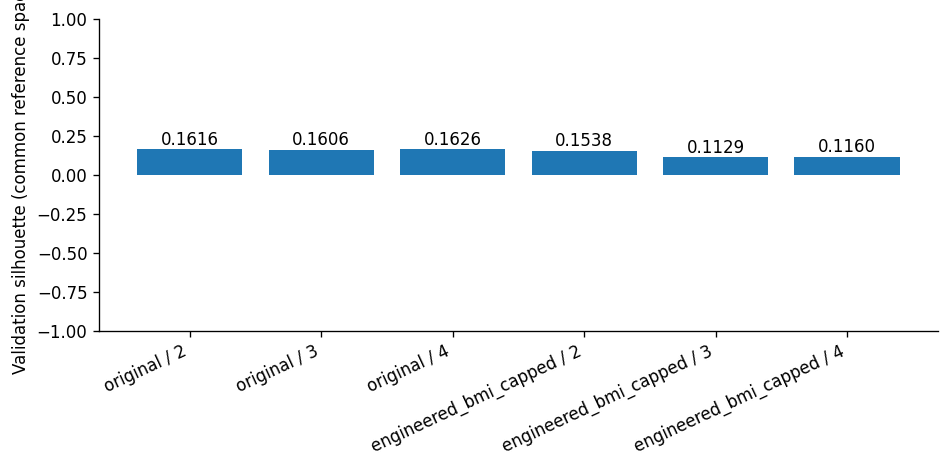

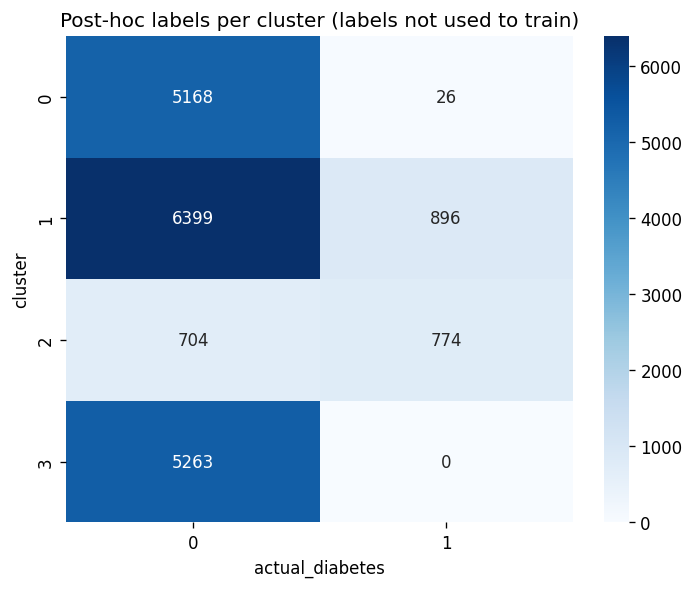

,representation,k,validation_silhouette
0,original,2,0.161572
1,original,3,0.160594
2,original,4,0.162587
3,engineered_bmi_capped,2,0.153813
4,engineered_bmi_capped,3,0.112895
5,engineered_bmi_capped,4,0.116001


actual_diabetes,0,1,count,positive_rate
cluster,,,,
0,5168,26,5194,0.005006
1,6399,896,7295,0.122824
2,704,774,1478,0.523681
3,5263,0,5263,0.000000


,member,model,kind,selected,validation_silhouette,test_silhouette,reference_space,sample_rows
0,5,KMeans,clustering,original / k=4,0.162587,0.16095,"original standardized numeric, binary passthro...",2000


In [3]:
result,variants,composition=cluster_experiments(PROJECT_ROOT,X_train,X_test,y_test)
display(variants)
display(composition)
display(pd.DataFrame([result]))

## 03 · Interpretation
Cluster IDs are arbitrary. The label composition table is not classifier accuracy. The saved pipeline predicts cluster IDs, not diabetes classes.